# Simulate a Biased Coin and Extract Unbiased Results

This notebook shows how a biased coin can be used to generate unbiased coin-flip results.

The key idea is the **Von Neumann extractor**:

- Toss the biased coin twice.
- If the pair is `HT`, output `H`.
- If the pair is `TH`, output `T`.
- If the pair is `HH` or `TT`, discard the pair.

Why this works:
  
  | Pair | Probability | Output |
  |---|---|---|
  | HT | p(1-p) | 1 |
  | TH | (1-p)p | 0 |
  | HH | p²     | discard |
  | TT | (1-p)² | discard |


  Since P(HT) = P(TH) = p(1-p), the kept outputs are perfectly fair
  regardless of p.


So `HT` and `TH` are equally likely, even when the coin itself is biased.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)

## 1. Simulate a biased coin

Let the probability of Heads be high, for example:

\[
P(H) = 0.7
\]

This is clearly not a fair coin.

In [2]:
p_heads = 0.7
n_flips = 100_000

# H = 1, T = 0
biased_flips = rng.choice([1, 0], size=n_flips, p=[p_heads, 1 - p_heads])

raw_heads = biased_flips.sum()
raw_tails = n_flips - raw_heads

raw_summary = pd.DataFrame({
    "Result": ["Heads", "Tails"],
    "Count": [raw_heads, raw_tails],
    "Proportion": [raw_heads / n_flips, raw_tails / n_flips]
})

raw_summary

,Result,Count,Proportion
0,Heads,69969,0.69969
1,Tails,30031,0.30031


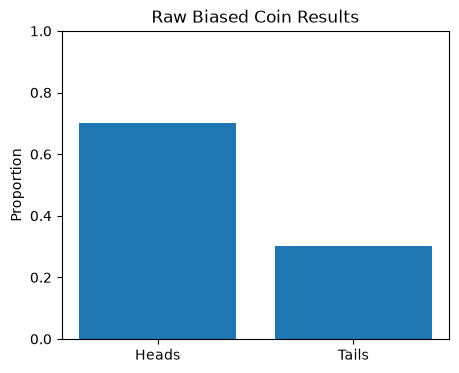

In [3]:
plt.figure(figsize=(5, 4))
plt.bar(raw_summary["Result"], raw_summary["Proportion"])
plt.ylim(0, 1)
plt.title("Raw Biased Coin Results")
plt.ylabel("Proportion")
plt.show()

## 2. Convert biased flips into unbiased flips

Now we group flips into pairs:

| Pair | Action |
|---|---|
| `HT` | Output `H` |
| `TH` | Output `T` |
| `HH` | Discard |
| `TT` | Discard |

This removes the bias, but it also discards some data.

In [4]:
def von_neumann_extractor(flips):
    flips = np.asarray(flips, dtype=np.uint8)

    even_length = len(flips) & ~1  # round down to even
    pairs = flips[:even_length].reshape(-1, 2)

    first = pairs[:, 0]
    second = pairs[:, 1]

    valid_mask = first != second
    unbiased_flips = first[valid_mask]

    discarded_pairs = (~valid_mask).sum()

    return unbiased_flips, discarded_pairs

In [5]:
unbiased_flips, discarded_pairs = von_neumann_extractor(biased_flips)

unbiased_heads = unbiased_flips.sum()
unbiased_tails = len(unbiased_flips) - unbiased_heads

unbiased_summary = pd.DataFrame({
    "Result": ["Heads", "Tails"],
    "Count": [unbiased_heads, unbiased_tails],
    "Proportion": [unbiased_heads / len(unbiased_flips), unbiased_tails / len(unbiased_flips)]
})

print(f"Original flips: {len(biased_flips):,}")
print(f"Number of pairs: {len(biased_flips) // 2:,}")
print(f"Unbiased flips produced: {len(unbiased_flips):,}")
print(f"Discarded pairs: {discarded_pairs:,}")

unbiased_summary

Original flips: 100,000
Number of pairs: 50,000
Unbiased flips produced: 20,883
Discarded pairs: 29,117


,Result,Count,Proportion
0,Heads,10547,0.505052
1,Tails,10336,0.494948


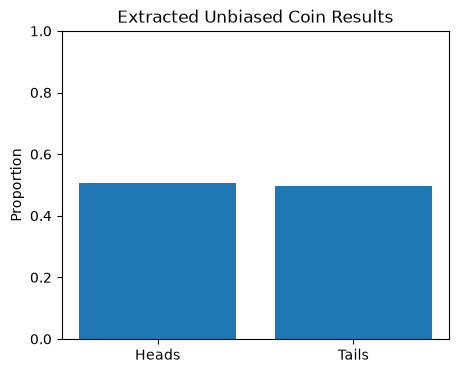

In [6]:
plt.figure(figsize=(5, 4))
plt.bar(unbiased_summary["Result"], unbiased_summary["Proportion"])
plt.ylim(0, 1)
plt.title("Extracted Unbiased Coin Results")
plt.ylabel("Proportion")
plt.show()

## 3. Compare biased vs extracted results

The original coin is biased toward Heads, but the extracted results should be close to 50-50.

In [7]:
comparison = pd.DataFrame({
    "Source": ["Original biased coin", "Extracted unbiased coin"],
    "Heads proportion": [raw_heads / n_flips, unbiased_heads / len(unbiased_flips)],
    "Tails proportion": [raw_tails / n_flips, unbiased_tails / len(unbiased_flips)]
})

comparison

,Source,Heads proportion,Tails proportion
0,Original biased coin,0.699690,0.300310
1,Extracted unbiased coin,0.505052,0.494948


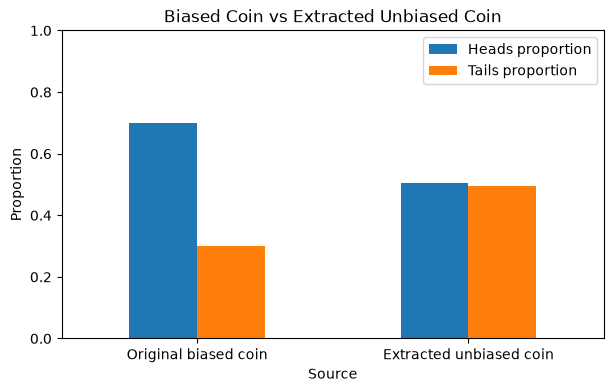

In [8]:
comparison.plot(
    x="Source",
    y=["Heads proportion", "Tails proportion"],
    kind="bar",
    figsize=(7, 4),
    ylim=(0, 1),
    title="Biased Coin vs Extracted Unbiased Coin"
)
plt.ylabel("Proportion")
plt.xticks(rotation=0)
plt.show()

## 4. Test different levels of bias

The method works for many different biases, as long as:

\[
0 < P(H) < 1
\]

If the coin always gives Heads or always gives Tails, then no unbiased result can be extracted.

In [9]:
def run_experiment(p_heads, n_flips=100_000):
    flips = rng.choice([1, 0], size=n_flips, p=[p_heads, 1 - p_heads])
    extracted, discarded = von_neumann_extractor(flips)

    if len(extracted) == 0:
        return {
            "P(H) biased coin": p_heads,
            "Extracted flips": 0,
            "Extracted P(H)": np.nan,
            "Extracted P(T)": np.nan,
            "Discarded pairs": discarded
        }

    return {
        "P(H) biased coin": p_heads,
        "Extracted flips": len(extracted),
        "Extracted P(H)": extracted.mean(),
        "Extracted P(T)": 1 - extracted.mean(),
        "Discarded pairs": discarded
    }

bias_values = [0.1, 0.2, 0.3, 0.5, 0.7, 0.8, 0.9]
results = pd.DataFrame([run_experiment(p) for p in bias_values])
results

,P(H) biased coin,Extracted flips,Extracted P(H),Extracted P(T),Discarded pairs
0,0.1,8963,0.497043,0.502957,41037
1,0.2,16044,0.503366,0.496634,33956
2,0.3,21135,0.502153,0.497847,28865
3,0.5,25138,0.499284,0.500716,24862
4,0.7,20950,0.501718,0.498282,29050
5,0.8,16099,0.498665,0.501335,33901
6,0.9,9045,0.501493,0.498507,40955


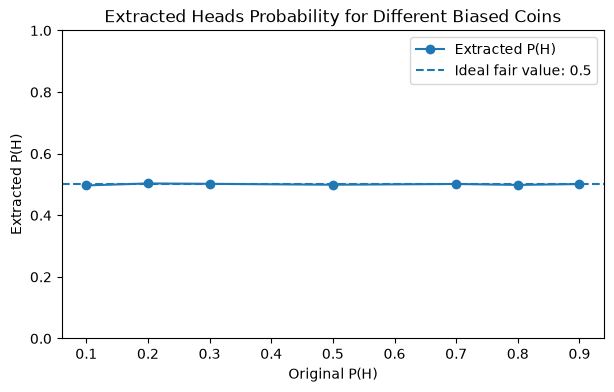

In [10]:
plt.figure(figsize=(7, 4))
plt.plot(results["P(H) biased coin"], results["Extracted P(H)"], marker="o", label="Extracted P(H)")
plt.axhline(0.5, linestyle="--", label="Ideal fair value: 0.5")
plt.ylim(0, 1)
plt.title("Extracted Heads Probability for Different Biased Coins")
plt.xlabel("Original P(H)")
plt.ylabel("Extracted P(H)")
plt.legend()
plt.show()

## Conclusion

A biased coin can be used to generate unbiased results by comparing pairs of tosses.

The cost is efficiency: many pairs may be discarded, especially when the coin is extremely biased.